In [2]:
from tool2 import *
device = 'mps' # cpu, cuda


In [4]:
X, Wq, Wk, Wv = make_3token_demo(d=4, seed=1)
print('X shape:', X.shape)
print('Wq shape:', Wq.shape)
print('Wk shape:', Wk.shape)
print('Wv shape:', Wv.shape)

X shape: (3, 4)
Wq shape: (4, 4)
Wk shape: (4, 4)
Wv shape: (4, 4)


In [11]:
X

array([[ 0.34558419,  0.82161814,  0.33043708, -1.30315723],
       [ 0.90535587,  0.44637457, -0.53695324,  0.5811181 ],
       [ 0.3645724 ,  0.2941325 ,  0.02842224,  0.54671299]])

In [7]:
Q = X @ Wq
K = X @ Wk
V = X @ Wv
print('Q\n', np.round(Q, 2))
print('K\n', np.round(K, 2))
print('V\n', np.round(V, 2))

Q
 [[ 0.99  0.62 -0.05  0.26]
 [-0.67 -0.37 -0.47 -0.11]
 [-0.52 -0.36 -0.14 -0.02]]
K
 [[ 0.36  0.63  0.42  0.43]
 [-0.12  0.48  0.62 -0.4 ]
 [-0.22  0.08  0.28 -0.22]]
V
 [[-0.15  0.19  0.66 -0.24]
 [ 0.09  0.22 -0.31 -0.13]
 [ 0.2   0.08 -0.17 -0.19]]


In [10]:
def numpy_self_attention(X: np.ndarray, Wq: np.ndarray, Wk: np.ndarray, Wv: np.ndarray):
    """X: (N, d) — 세 토큰 짜리 mini 예제용. attention 가중치도 함께 반환."""
    Q, K, V = X @ Wq, X @ Wk, X @ Wv
    d_k = Q.shape[-1]
    scores = Q @ K.T / math.sqrt(d_k)
    A = numpy_softmax(scores, axis=-1)
    return A @ V, A

# 한 줄짜리 numpy_self_attention
out, A = numpy_self_attention(X, Wq, Wk, Wv)
print('attention matrix A:\n', np.round(A, 2))

# sum을 했을때 1이 나와야 한다 (axis=?) 

attention matrix A:
 [[0.44 0.3  0.26]
 [0.27 0.33 0.39]
 [0.29 0.33 0.38]]


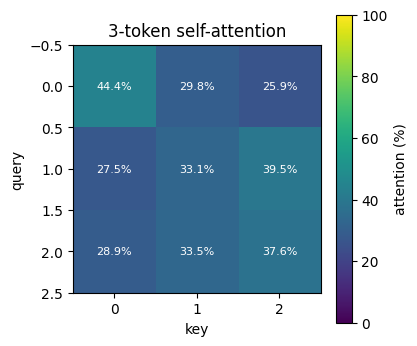

In [12]:
# 작은 행렬이지만 패턴을 본다
import matplotlib.pyplot as plt
plot_attention_matrix(A, title='3-token self-attention'); plt.show()